<a href="https://colab.research.google.com/github/Adrian-estrada-chavez/clothing-sales-roi-analysis/blob/main/notebooks/Clothing_sales_roi_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Definición del objetivo

Analizar el desempeño de ventas en un negocio de ropa para identificar las categorías y productos con mayor rotación y rentabilidad, con el fin de optimizar la toma de decisiones en inventario y maximizar el retorno de inversión (ROI).

#2. Exploración rápida de datos

Se realizó una exploración rápida en PostgreSQL para entender la estructura general de los datos, incluyendo tablas, columnas y relaciones clave.
Esta etapa permitió comprender el modelo de datos antes de realizar un análisis más profundo en Pyhton.

##2.1.Exploración inicial

La exploración inicial se realizó utilizando consultas básicas en SQL para:

- Identificar tablas disponibles.

- Visualizar registros de ejemplo.

- Revisar estructura de los datos.

```sql
\dt para listar tablas

select * from "public"."tabla" limit 10;
para visualizar las columnas.

##2.2.  Tablas principales

- clientes: información de clientes.

- compras: registro de compras a proveedores.

- detalle_compra: productos incluidos en cada compra.

- detalle_ntc:  productos incluidos por devolución.

- detalle_venta: productos incluidos en cada venta.

- notas_credito: devoluciones de clientes.

- personal: empleados de la empresa.

- productos: catálogo de productos y categorias.

- sucursales: sucursales de la empresa.

- ventas: registros de ventas realizadas.

#3. Extracción y almacenamiento de datos

Se realizó la extracción de datos desde PostgreSQL, exportando las tablas relevantes de manera individual en formato CSV para su posterior análisis.

La exportación se llevó a cabo mediante consultas SQL utilizando el comando:


```sql
set client_encoding TO 'utf8';
\copy nombre_tabla TO 'C:/ruta/data/raw/nombre_tabla.csv' CSV HEADER;

Los archivos generados fueron almacenados en una estructura organizada de carpetas (data/raw) y posteriormente integrados en un repositorio de GitHub.

Esto permitió su carga y análisis en Python a través de Google Colab, facilitando la reproducibilidad del proyecto y la separación entre la capa de almacenamiento y la de análisis.

# 4. Carga y validación de datos

Los datos fueron almacendados en un repositorio de GitHub y posteriormente cargados en el entorno de análisis utilizando Google Colab.

Para ello se utilizaron archivos en formato CSV alojados en el repositorio, los cuales fueron importados directamente mediante Python

## 4.1 Importación de datos a colab

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [105]:
clientes_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/clientes.csv'
clientes_raw = pd.read_csv(clientes_raw_url)

In [106]:
compras_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/compras.csv'
compras_raw = pd.read_csv(compras_raw_url)

In [107]:
dcompra_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/detalle_compra.csv'
dcompra_raw = pd.read_csv(dcompra_raw_url)

In [108]:
dntc_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/detalle_ntc.csv'
dntc_raw = pd.read_csv(dntc_raw_url)

In [109]:
dventa_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/detalle_venta.csv'
dventa_raw = pd.read_csv(dventa_raw_url)

In [110]:
ntc_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/notas_credito.csv'
ntc_raw = pd.read_csv(ntc_raw_url)

In [111]:
personal_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/personal.csv'
personal_raw = pd.read_csv(personal_raw_url)

In [112]:
productos_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/productos.csv'
productos_raw = pd.read_csv(productos_raw_url)

In [113]:
sucursales_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/sucursales.csv'
sucursales_raw = pd.read_csv(sucursales_raw_url)

In [114]:
ventas_raw_url = 'https://raw.githubusercontent.com/Adrian-estrada-chavez/clothing-sales-roi-analysis/main/data_raw/ventas.csv'
ventas_raw = pd.read_csv(ventas_raw_url)

## 4.2 Validación inicial de datos

Se realizó una validación de los datos para verificar su estructura, tipos de datos y consistencia antes del proceso de limpieza y análisis

In [115]:
clientes_raw.head(10)

,id_cliente,nombre_cliente,ciudad,estado,codigo_postal,telefono,descuento,tipo_cliente
0,1,publico en general,xxxx,michoacan,59000,353-123-45-67,0,menudeo


In [116]:
clientes_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_cliente      1 non-null      int64 
 1   nombre_cliente  1 non-null      object
 2   ciudad          1 non-null      object
 3   estado          1 non-null      object
 4   codigo_postal   1 non-null      int64 
 5   telefono        1 non-null      object
 6   descuento       1 non-null      int64 
 7   tipo_cliente    1 non-null      object
dtypes: int64(3), object(5)
memory usage: 196.0+ bytes


In [117]:
compras_raw.head(10)

,folio,fecha,marca,cantidad,subtotal,total
0,PO-000001,2024-01-04,GEEGEE,18,4662,5407.92
1,PO-000002,2024-01-04,INA,18,5220,6055.20
2,PO-000003,2024-01-04,HAVE,183,39753,46113.48
3,PO-000004,2024-01-04,BLASHE,51,8682,10071.12
4,PO-000005,2024-01-04,AJ LEE APPAREL,51,8832,10245.12
5,PO-000006,2024-01-04,ACG,93,18963,21997.08
6,PO-000007,2024-01-04,MINE,276,56850,65946.00
7,PO-000008,2024-01-04,CHOCOLATE,42,10230,11866.80
8,PO-000009,2024-01-04,STELLA,18,1521,1764.36
9,PO-000010,2024-01-04,SPRING HAZE,42,10296,11943.36


In [118]:
compras_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   folio     1007 non-null   object 
 1   fecha     1007 non-null   object 
 2   marca     1007 non-null   object 
 3   cantidad  1007 non-null   int64  
 4   subtotal  1007 non-null   int64  
 5   total     1007 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 47.3+ KB


In [119]:
dcompra_raw.head(10)

,folio,sku,descripcion,cantidad,precio_unitario,impuesto,descuento,subtotal,importe,fecha,registro_nombre,usuario_autorizo_nombre,marca
0,PO-000001,GEE-0001,TOP DE TEJIDO DENIM BEIGE,9,265,16,0,2385,2766.60,2024-01-04,USUARIO1,ADMIN1,GEEGEE
1,PO-000001,GEE-0002,BLUSA ACANALADO CREMA,9,253,16,0,2277,2641.32,2024-01-04,USUARIO1,ADMIN1,GEEGEE
2,PO-000002,INA-0001,ENTERIZO CON LAZADA NEGRO,9,291,16,0,2619,3038.04,2024-01-04,USUARIO1,ADMIN1,INA
3,PO-000002,INA-0002,ENTERIZO CON BORDADO SUIZO CREMA,9,289,16,0,2601,3017.16,2024-01-04,USUARIO1,ADMIN1,INA
4,PO-000003,HAV-0001,PANTALON DE LINO AZUL MARINO,18,149,16,0,2682,3111.12,2024-01-04,USUARIO1,ADMIN1,HAVE
5,PO-000003,HAV-0002,PANTALON DE LINO VERDE ESMERALDA,18,258,16,0,4644,5387.04,2024-01-04,USUARIO1,ADMIN1,HAVE
6,PO-000003,HAV-0003,FALDA CON CUELLO EN V GRIS JASPE,18,268,16,0,4824,5595.84,2024-01-04,USUARIO1,ADMIN1,HAVE
7,PO-000003,HAV-0004,CROP TOP DE LINO BURDEOS,18,252,16,0,4536,5261.76,2024-01-04,USUARIO1,ADMIN1,HAVE
8,PO-000003,HAV-0005,BLUSA CON BORDADO SUIZO AZUL MARINO,18,258,16,0,4644,5387.04,2024-01-04,USUARIO1,ADMIN1,HAVE
9,PO-000003,HAV-0006,PANTALON DE CORTE RECTO TERRACOTA,18,286,16,0,5148,5971.68,2024-01-04,USUARIO1,ADMIN1,HAVE


In [120]:
dcompra_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7649 entries, 0 to 7648
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   folio                    7649 non-null   object 
 1   sku                      7649 non-null   object 
 2   descripcion              7649 non-null   object 
 3   cantidad                 7649 non-null   int64  
 4   precio_unitario          7649 non-null   int64  
 5   impuesto                 7649 non-null   int64  
 6   descuento                7649 non-null   int64  
 7   subtotal                 7649 non-null   int64  
 8   importe                  7649 non-null   float64
 9   fecha                    7649 non-null   object 
 10  registro_nombre          7649 non-null   object 
 11  usuario_autorizo_nombre  7649 non-null   object 
 12  marca                    7649 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 777.0+ KB


In [121]:
dntc_raw.head(10)

,id_ntc,id_venta,id_cliente,fecha,sku,descripcion,cantidad,precio,total
0,NTC-000001,NOT-000012,1,2024-01-05,MIN-0007,PANTALON CON OLANES NEGRO,1,255,255
1,NTC-000002,NOT-000019,1,2024-01-06,MIC-0002,FALDA DE LINO TERRACOTA,1,270,270
2,NTC-000003,NOT-000020,1,2024-01-06,ACT-0001,CARDIGAN DE TEJIDO DENIM TERRACOTA,1,342,342
3,NTC-000004,NOT-000023,1,2024-01-06,OVI-0008,CARDIGAN AJUSTADO ROSA PASTEL,1,400,400
4,NTC-000005,NOT-000078,1,2024-01-07,GAL-0012,FALDA CON BORDADO SUIZO MOSTAZA,1,201,201
5,NTC-000006,NOT-000093,1,2024-01-07,GAL-0012,FALDA CON BORDADO SUIZO MOSTAZA,1,201,201
6,NTC-000007,NOT-000099,1,2024-01-07,HAV-0002,PANTALON DE LINO VERDE ESMERALDA,1,310,310
7,NTC-000008,NOT-000125,1,2024-01-08,ACT-0013,CARDIGAN SATINADO LILA,1,232,232
8,NTC-000009,NOT-000154,1,2024-01-08,ONE-0001,TOP ACANALADO TERRACOTA,1,424,424
9,NTC-000010,NOT-000192,1,2024-01-09,PAP-0011,CAMISA PLISADO AZUL CIELO,1,216,216


In [122]:
dntc_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id_ntc       2215 non-null   object
 1   id_venta     2215 non-null   object
 2   id_cliente   2215 non-null   int64 
 3   fecha        2215 non-null   object
 4   sku          2215 non-null   object
 5   descripcion  2215 non-null   object
 6   cantidad     2215 non-null   int64 
 7   precio       2215 non-null   int64 
 8   total        2215 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 155.9+ KB


In [123]:
dventa_raw.head(10)

,id_venta,fecha,id_sucursal,id_cliente,sku,descripcion_producto,marca,cantidad,precio_venta_producto,descuento,iva,subtotal,total
0,NOT-000001,2024-01-05,1,1,HAV-0007,CROP TOP ACANALADO CREMA,HAVE,1,193,0,16,193,224
1,NOT-000002,2024-01-05,1,1,OVI-0010,BLUSA OVERSIZE ROSA PASTEL,OVI,1,318,0,16,318,369
2,NOT-000002,2024-01-05,1,1,SPR-0004,PANTALON AJUSTADO AZUL CIELO,SPRING HAZE,1,320,0,16,320,371
3,NOT-000002,2024-01-05,1,1,ACT-0011,CROP TOP CON BORDADO SUIZO AZUL CIELO,ACTIVE USA,1,190,0,16,190,220
4,NOT-000002,2024-01-05,1,1,HAV-0005,BLUSA CON BORDADO SUIZO AZUL MARINO,HAVE,1,310,0,16,310,360
5,NOT-000003,2024-01-05,1,1,ACT-0013,CARDIGAN SATINADO LILA,ACTIVE USA,1,232,0,16,232,269
6,NOT-000003,2024-01-05,1,1,MIN-0005,CARDIGAN DE TEJIDO DENIM MOSTAZA,MINE,1,251,0,16,251,291
7,NOT-000003,2024-01-05,1,1,MIN-0003,TOP SATINADO AZUL MARINO,MINE,1,215,0,16,215,249
8,NOT-000004,2024-01-05,1,1,MIN-0008,BLUSA ACANALADO MOSTAZA,MINE,1,244,0,16,244,283
9,NOT-000005,2024-01-05,1,1,HAV-0009,CROP TOP DE CORTE RECTO GRIS JASPE,HAVE,1,207,0,16,207,240


In [124]:
dventa_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126469 entries, 0 to 126468
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   id_venta               126469 non-null  object
 1   fecha                  126469 non-null  object
 2   id_sucursal            126469 non-null  int64 
 3   id_cliente             126469 non-null  int64 
 4   sku                    126469 non-null  object
 5   descripcion_producto   126469 non-null  object
 6   marca                  126469 non-null  object
 7   cantidad               126469 non-null  int64 
 8   precio_venta_producto  126469 non-null  int64 
 9   descuento              126469 non-null  int64 
 10  iva                    126469 non-null  int64 
 11  subtotal               126469 non-null  int64 
 12  total                  126469 non-null  int64 
dtypes: int64(8), object(5)
memory usage: 12.5+ MB


In [125]:
ntc_raw.head(10)

,id_ntc,id_cliente,cantidad,precio,total
0,NTC-000001,1,1,255,255
1,NTC-000002,1,1,270,270
2,NTC-000003,1,1,342,342
3,NTC-000004,1,1,400,400
4,NTC-000005,1,1,201,201
5,NTC-000006,1,1,201,201
6,NTC-000007,1,1,310,310
7,NTC-000008,1,1,232,232
8,NTC-000009,1,1,424,424
9,NTC-000010,1,1,216,216


In [126]:
ntc_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_ntc      2215 non-null   object
 1   id_cliente  2215 non-null   int64 
 2   cantidad    2215 non-null   int64 
 3   precio      2215 non-null   int64 
 4   total       2215 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 86.7+ KB


In [127]:
personal_raw.head(10)

,id_personal,id_sucursal,nombre_personal,departamento,puesto
0,1,1,MARIANA PEREZ,VENTAS,CAJERO
1,2,1,ISABEL MATIAS,VENTAS,CAJERO
2,3,1,PAOLA RAMIREZ,VENTAS,CAJERO
3,4,1,MONSERRAT INOCENCIO,VENTAS,CAJERO
4,5,1,GABRIEL ALFARO,VENTAS,CAJERO
5,6,1,SOFIA GUDIÑO,VENTAS,CAJERO
6,7,1,JESUS OMAR GALINDO,ALMACEN,AUXILIAR
7,8,1,ANA TORROJA,ALMACEN,AUXILIAR
8,9,1,JOSE LUIS MANZO,ALMACEN,JEFE
9,10,1,MARIO OCHOA,ALMACEN,AUXILIAR


In [128]:
personal_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_personal      12 non-null     int64 
 1   id_sucursal      12 non-null     int64 
 2   nombre_personal  12 non-null     object
 3   departamento     12 non-null     object
 4   puesto           12 non-null     object
dtypes: int64(2), object(3)
memory usage: 612.0+ bytes


In [129]:
productos_raw.head(10)

,sku,id_producto,nombre_producto,modelo,color,talla,categoria,marca,precio_venta,costo,fecha,tipo_producto,unidad_medida,codigo_barras,Tipo_producto_afecta_inventario
0,GEE-0001,1,TOP DE TEJIDO DENIM BEIGE,NaN,NaN,NaN,TOP,GEEGEE,318,265,2024-01-04,Inventariable,Pieza,50000001,True
1,GEE-0002,2,BLUSA ACANALADO CREMA,NaN,NaN,NaN,BLUSA,GEEGEE,304,253,2024-01-04,Inventariable,Pieza,50000002,True
2,INA-0001,3,ENTERIZO CON LAZADA NEGRO,NaN,NaN,NaN,ENTERIZO,INA,350,291,2024-01-04,Inventariable,Pieza,50000003,True
3,INA-0002,4,ENTERIZO CON BORDADO SUIZO CREMA,NaN,NaN,NaN,ENTERIZO,INA,347,289,2024-01-04,Inventariable,Pieza,50000004,True
4,HAV-0001,5,PANTALON DE LINO AZUL MARINO,NaN,NaN,NaN,PANTALON,HAVE,194,149,2024-01-04,Inventariable,Pieza,50000005,True
5,HAV-0002,6,PANTALON DE LINO VERDE ESMERALDA,NaN,NaN,NaN,PANTALON,HAVE,310,258,2024-01-04,Inventariable,Pieza,50000006,True
6,HAV-0003,7,FALDA CON CUELLO EN V GRIS JASPE,NaN,NaN,NaN,FALDA,HAVE,322,268,2024-01-04,Inventariable,Pieza,50000007,True
7,HAV-0004,8,CROP TOP DE LINO BURDEOS,NaN,NaN,NaN,CROP,HAVE,303,252,2024-01-04,Inventariable,Pieza,50000008,True
8,HAV-0005,9,BLUSA CON BORDADO SUIZO AZUL MARINO,NaN,NaN,NaN,BLUSA,HAVE,310,258,2024-01-04,Inventariable,Pieza,50000009,True
9,HAV-0006,10,PANTALON DE CORTE RECTO TERRACOTA,NaN,NaN,NaN,PANTALON,HAVE,344,286,2024-01-04,Inventariable,Pieza,50000010,True


In [130]:
productos_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7649 entries, 0 to 7648
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   sku                              7649 non-null   object 
 1   id_producto                      7649 non-null   int64  
 2   nombre_producto                  7649 non-null   object 
 3   modelo                           0 non-null      float64
 4   color                            0 non-null      float64
 5   talla                            0 non-null      float64
 6   categoria                        7649 non-null   object 
 7   marca                            7649 non-null   object 
 8   precio_venta                     7649 non-null   int64  
 9   costo                            7649 non-null   int64  
 10  fecha                            7649 non-null   object 
 11  tipo_producto                    7649 non-null   object 
 12  unidad_medida       

In [131]:
sucursales_raw.head(10)

,id_sucursal,encargado,ciudad,estado,telefono
0,1,LUIS MORENO,XXXXX,MICHOACAN,353-123-45-67


In [132]:
sucursales_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id_sucursal  1 non-null      int64 
 1   encargado    1 non-null      object
 2   ciudad       1 non-null      object
 3   estado       1 non-null      object
 4   telefono     1 non-null      object
dtypes: int64(1), object(4)
memory usage: 172.0+ bytes


In [133]:
ventas_raw.head(10)

,id_venta,id_sucursal,fecha,subtotal,iva,total,realizo
0,NOT-000001,1,2024-01-05,193,31,224,MONSERRAT INOCENCIO
1,NOT-000002,1,2024-01-05,1138,182,1320,GABRIEL ALFARO
2,NOT-000003,1,2024-01-05,698,111,809,ISABEL MATIAS
3,NOT-000004,1,2024-01-05,244,39,283,MARIANA PEREZ
4,NOT-000005,1,2024-01-05,931,149,1080,MONSERRAT INOCENCIO
5,NOT-000006,1,2024-01-05,662,106,768,SOFIA GUDIÑO
6,NOT-000007,1,2024-01-05,1100,176,1276,ISABEL MATIAS
7,NOT-000008,1,2024-01-05,791,127,918,GABRIEL ALFARO
8,NOT-000009,1,2024-01-05,190,30,220,PAOLA RAMIREZ
9,NOT-000010,1,2024-01-05,1425,229,1654,MONSERRAT INOCENCIO


In [134]:
ventas_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39052 entries, 0 to 39051
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id_venta     39052 non-null  object
 1   id_sucursal  39052 non-null  int64 
 2   fecha        39052 non-null  object
 3   subtotal     39052 non-null  int64 
 4   iva          39052 non-null  int64 
 5   total        39052 non-null  int64 
 6   realizo      39052 non-null  object
dtypes: int64(4), object(3)
memory usage: 2.1+ MB


## 5 Limpieza de datos

Se realizó un proceso de limpieza de datos para asegurar la consistencia, integridad y calidad de la información antes del análisis.

Las acciones incluyeron la estandarización de tipos de datos, la identificación y tratamiento de valores nulos, la eliminación de duplicados y la validación de consistencia en las variables clave.

Este proceso permitió preparar los datos para su correcta integración y análisis posterior.

por su naturaleza se eliminaran del análisis las tablas:
- clientes: solo existe publico en general.
- nota_credito: se requiere todos los detalles y la tabla dntc los tiene.
- personal: su id no esta conectado a nada y la tabla venta tiene los nombres.
- sucursal: solo existe una sucursal.

### 5.1 Tipo de datos

durante la validación de datos se observo los tipos de datos y se detectaron inconsistencias en las columnas utilizadas como claves de unión entre tablas y en fechas.
asi que aprovechando estandarizaré con mayusculas las columnas clave.

In [135]:
compras_raw['fecha']=pd.to_datetime(compras_raw['fecha'], errors='coerce', utc=True)
compras_raw=compras_raw.rename(columns={'folio':'id_compra'})
compras_raw['id_compra']=compras_raw['id_compra'].astype('string').str.upper()
compras_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   id_compra  1007 non-null   string             
 1   fecha      1007 non-null   datetime64[ns, UTC]
 2   marca      1007 non-null   object             
 3   cantidad   1007 non-null   int64              
 4   subtotal   1007 non-null   int64              
 5   total      1007 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(1), int64(2), object(1), string(1)
memory usage: 47.3+ KB


In [136]:
dcompra_raw=dcompra_raw.rename(columns={'folio':'id_compra'})
dcompra_raw['id_compra']=dcompra_raw['id_compra'].astype('string').str.upper()
dcompra_raw['sku']=dcompra_raw['sku'].astype('string').str.upper()
dcompra_raw['fecha']=pd.to_datetime(dcompra_raw['fecha'], errors='coerce', utc=True)
dcompra_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7649 entries, 0 to 7648
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   id_compra                7649 non-null   string             
 1   sku                      7649 non-null   string             
 2   descripcion              7649 non-null   object             
 3   cantidad                 7649 non-null   int64              
 4   precio_unitario          7649 non-null   int64              
 5   impuesto                 7649 non-null   int64              
 6   descuento                7649 non-null   int64              
 7   subtotal                 7649 non-null   int64              
 8   importe                  7649 non-null   float64            
 9   fecha                    7649 non-null   datetime64[ns, UTC]
 10  registro_nombre          7649 non-null   object             
 11  usuario_autorizo_nombre  7649 

In [137]:
dntc_raw['id_ntc']=dntc_raw['id_ntc'].astype('string').str.upper()
dntc_raw['id_venta']=dntc_raw['id_venta'].astype('string').str.upper()
dntc_raw['sku']=dntc_raw['sku'].astype('string').str.upper()
dntc_raw['fecha']=pd.to_datetime(dntc_raw['fecha'],errors='coerce',utc=True)
dntc_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   id_ntc       2215 non-null   string             
 1   id_venta     2215 non-null   string             
 2   id_cliente   2215 non-null   int64              
 3   fecha        2215 non-null   datetime64[ns, UTC]
 4   sku          2215 non-null   string             
 5   descripcion  2215 non-null   object             
 6   cantidad     2215 non-null   int64              
 7   precio       2215 non-null   int64              
 8   total        2215 non-null   int64              
dtypes: datetime64[ns, UTC](1), int64(4), object(1), string(3)
memory usage: 155.9+ KB


In [138]:
ventas_raw['id_venta']=ventas_raw['id_venta'].astype('string').str.upper()
ventas_raw['fecha']=pd.to_datetime(ventas_raw['fecha'],errors='coerce',utc=True)
ventas_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39052 entries, 0 to 39051
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   id_venta     39052 non-null  string             
 1   id_sucursal  39052 non-null  int64              
 2   fecha        39052 non-null  datetime64[ns, UTC]
 3   subtotal     39052 non-null  int64              
 4   iva          39052 non-null  int64              
 5   total        39052 non-null  int64              
 6   realizo      39052 non-null  object             
dtypes: datetime64[ns, UTC](1), int64(4), object(1), string(1)
memory usage: 2.1+ MB


In [139]:
dventa_raw['id_venta']=dventa_raw['id_venta'].astype('string').str.upper()
dventa_raw['sku']=dventa_raw['sku'].astype('string').str.upper()
dventa_raw['fecha']=pd.to_datetime(dventa_raw['fecha'],errors='coerce',utc=True)
dventa_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126469 entries, 0 to 126468
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   id_venta               126469 non-null  string             
 1   fecha                  126469 non-null  datetime64[ns, UTC]
 2   id_sucursal            126469 non-null  int64              
 3   id_cliente             126469 non-null  int64              
 4   sku                    126469 non-null  string             
 5   descripcion_producto   126469 non-null  object             
 6   marca                  126469 non-null  object             
 7   cantidad               126469 non-null  int64              
 8   precio_venta_producto  126469 non-null  int64              
 9   descuento              126469 non-null  int64              
 10  iva                    126469 non-null  int64              
 11  subtotal               126469 non-null 

In [140]:
productos_raw['sku']=productos_raw['sku'].astype('string').str.upper()
productos_raw['fecha']=pd.to_datetime(productos_raw['fecha'],errors='coerce',utc=True)
productos_raw['categoria']=productos_raw['categoria'].astype('string').str.upper()
productos_raw['marca']=productos_raw['marca'].astype('string').str.upper()
productos_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7649 entries, 0 to 7648
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype              
---  ------                           --------------  -----              
 0   sku                              7649 non-null   string             
 1   id_producto                      7649 non-null   int64              
 2   nombre_producto                  7649 non-null   object             
 3   modelo                           0 non-null      float64            
 4   color                            0 non-null      float64            
 5   talla                            0 non-null      float64            
 6   categoria                        7649 non-null   string             
 7   marca                            7649 non-null   string             
 8   precio_venta                     7649 non-null   int64              
 9   costo                            7649 non-null   int64              
 10  

## 5.2 Datos nulos

Se realizó la identificación de valores nulos en las diferentes tablas con el objetivo de evaluar la integridad de los datos, evitar sesgos y asegurar la calidad de los resultados obtenidos.

In [141]:
compras_raw.isnull().sum()

,0
id_compra,0
fecha,0
marca,0
cantidad,0
subtotal,0
total,0


In [142]:
dcompra_raw.isnull().sum()

,0
id_compra,0
sku,0
descripcion,0
cantidad,0
precio_unitario,0
impuesto,0
descuento,0
subtotal,0
importe,0
fecha,0


In [143]:
dntc_raw.isnull().sum()

,0
id_ntc,0
id_venta,0
id_cliente,0
fecha,0
sku,0
descripcion,0
cantidad,0
precio,0
total,0


In [144]:
ventas_raw.isnull().sum()

,0
id_venta,0
id_sucursal,0
fecha,0
subtotal,0
iva,0
total,0
realizo,0


In [145]:
dventa_raw.isnull().sum()

,0
id_venta,0
fecha,0
id_sucursal,0
id_cliente,0
sku,0
descripcion_producto,0
marca,0
cantidad,0
precio_venta_producto,0
descuento,0


In [146]:
productos_raw.isnull().sum()

,0
sku,0
id_producto,0
nombre_producto,0
modelo,7649
color,7649
talla,7649
categoria,0
marca,0
precio_venta,0
costo,0


en este caso solo la tabla productos se encontraron valores nulos, los cuales dos de las tres columnas con dichos datos eran importante para un analisis mas preciso (color y talla).

In [147]:
productos_raw.head()

,sku,id_producto,nombre_producto,modelo,color,talla,categoria,marca,precio_venta,costo,fecha,tipo_producto,unidad_medida,codigo_barras,Tipo_producto_afecta_inventario
0,GEE-0001,1,TOP DE TEJIDO DENIM BEIGE,NaN,NaN,NaN,TOP,GEEGEE,318,265,2024-01-04 00:00:00+00:00,Inventariable,Pieza,50000001,True
1,GEE-0002,2,BLUSA ACANALADO CREMA,NaN,NaN,NaN,BLUSA,GEEGEE,304,253,2024-01-04 00:00:00+00:00,Inventariable,Pieza,50000002,True
2,INA-0001,3,ENTERIZO CON LAZADA NEGRO,NaN,NaN,NaN,ENTERIZO,INA,350,291,2024-01-04 00:00:00+00:00,Inventariable,Pieza,50000003,True
3,INA-0002,4,ENTERIZO CON BORDADO SUIZO CREMA,NaN,NaN,NaN,ENTERIZO,INA,347,289,2024-01-04 00:00:00+00:00,Inventariable,Pieza,50000004,True
4,HAV-0001,5,PANTALON DE LINO AZUL MARINO,NaN,NaN,NaN,PANTALON,HAVE,194,149,2024-01-04 00:00:00+00:00,Inventariable,Pieza,50000005,True


In [148]:
productos_raw['modelo']=productos_raw['modelo'].fillna('sin modelo')
productos_raw['color']=productos_raw['color'].fillna('sin color')
productos_raw['talla']=productos_raw['talla'].fillna('sin talla')
productos_raw.head()

,sku,id_producto,nombre_producto,modelo,color,talla,categoria,marca,precio_venta,costo,fecha,tipo_producto,unidad_medida,codigo_barras,Tipo_producto_afecta_inventario
0,GEE-0001,1,TOP DE TEJIDO DENIM BEIGE,sin modelo,sin color,sin talla,TOP,GEEGEE,318,265,2024-01-04 00:00:00+00:00,Inventariable,Pieza,50000001,True
1,GEE-0002,2,BLUSA ACANALADO CREMA,sin modelo,sin color,sin talla,BLUSA,GEEGEE,304,253,2024-01-04 00:00:00+00:00,Inventariable,Pieza,50000002,True
2,INA-0001,3,ENTERIZO CON LAZADA NEGRO,sin modelo,sin color,sin talla,ENTERIZO,INA,350,291,2024-01-04 00:00:00+00:00,Inventariable,Pieza,50000003,True
3,INA-0002,4,ENTERIZO CON BORDADO SUIZO CREMA,sin modelo,sin color,sin talla,ENTERIZO,INA,347,289,2024-01-04 00:00:00+00:00,Inventariable,Pieza,50000004,True
4,HAV-0001,5,PANTALON DE LINO AZUL MARINO,sin modelo,sin color,sin talla,PANTALON,HAVE,194,149,2024-01-04 00:00:00+00:00,Inventariable,Pieza,50000005,True


## 5.3 Valores duplicados

In [149]:
compras_raw.duplicated().sum()

np.int64(0)

In [150]:
dcompra_raw.duplicated().sum()

np.int64(0)

In [151]:
dntc_raw.duplicated().sum()

np.int64(0)

In [152]:
ventas_raw.duplicated().sum()

np.int64(0)

In [153]:
dventa_raw.duplicated().sum()

np.int64(578)

In [154]:
dventa_raw[dventa_raw.duplicated()]

,id_venta,fecha,id_sucursal,id_cliente,sku,descripcion_producto,marca,cantidad,precio_venta_producto,descuento,iva,subtotal,total
68,NOT-000021,2024-01-06 00:00:00+00:00,1,1,MIC-0008,CROP TOP DE LINO LILA,MICHEL,1,268,0,16,268,311
69,NOT-000021,2024-01-06 00:00:00+00:00,1,1,MIC-0008,CROP TOP DE LINO LILA,MICHEL,1,268,0,16,268,311
362,NOT-000118,2024-01-08 00:00:00+00:00,1,1,ACT-0005,PANTALON CON LAZADA AZUL MARINO,ACTIVE USA,1,376,0,16,376,436
759,NOT-000236,2024-01-10 00:00:00+00:00,1,1,LOR-0007,VESTIDO CON CUELLO EN V MOSTAZA,LOVERICHE,1,386,0,16,386,448
968,NOT-000298,2024-01-11 00:00:00+00:00,1,1,MIL-0001,CARDIGAN DE TEJIDO DENIM VERDE ESMERALDA,MILK & HONEY,1,255,0,16,255,296
...,...,...,...,...,...,...,...,...,...,...,...,...,...
126285,NOT-038975,2026-11-01 00:00:00+00:00,1,1,MIC-0298,CAMISA DE ENCAJE AZUL CIELO,MICHEL,1,293,0,16,293,340
126291,NOT-038977,2026-11-03 00:00:00+00:00,1,1,ACT-0343,TOP CON LAZADA CREMA,ACTIVE USA,1,114,0,16,114,132
126322,NOT-038989,2026-11-08 00:00:00+00:00,1,1,ACT-0316,ENTERIZO DE ENCAJE NEGRO,ACTIVE USA,1,311,0,16,311,361
126400,NOT-039020,2026-11-25 00:00:00+00:00,1,1,MIN-0270,TOP AJUSTADO BEIGE,MINE,1,207,0,16,207,240


En este caso se ecnontraron 13 columnas repetidas, sin embargo hablando con el equipo de almacén me comenta que raras veces al escanear un código repite el sku en vez de agruparlo asi que se considera que si fueron ventas legitimas.

Si  realmente fueran duplicados se eliminarian usando:
dventa_raw=dventa_raw.drop_duplicates()

In [155]:
productos_raw.duplicated().sum()

np.int64(0)

## 5.4 Validación de consistencia

como el análisis será por categoria y sku vemos si hay datos mal escritos para correguirlos.

In [156]:
productos_raw['categoria'].sort_values().unique()

<StringArray>
[   'BLUSA',   'CAMISA', 'CARDIGAN',     'CROP', 'ENTERIZO',    'FALDA',
 'PANTALON',    'SHORT',      'TOP',  'VESTIDO']
Length: 10, dtype: string

In [157]:
productos_raw['marca'].sort_values().unique()

<StringArray>
[                     'ACG',               'ACTIVE USA',
           'AJ LEE APPAREL',         'AMBIANCE APPAREL',
                'AVAILABLE',                    'AZURA',
                    'BAMBU',                'BETTER BE',
                   'BLASHE',                    'CAMEO',
                'CHOCOLATE',         'CI SONO CORDUROY',
                  'COLETTE',                    'CRETA',
             'DANIEL JEANS',                 'DAZZLING',
              'DOUBLE ZERO',                'DRESS DAY',
             'EDIT BY NINE',                  'ESTELLA',
                 'EVERLYNN', 'FASHION CARGO (PASSPORT)',
                   'GALITA',                   'GEEGEE',
                    'GILLI',                     'GLAM',
                     'HAVE',                    'HYFVE',
             'IF SHE LOVES',                    'IJOAH',
                 'IN 2 YOU',                      'INA',
                  'INVOICE',                     'IRIS',
                 

# 6 Integración de datos

## 6.1 validacion de union de tablas

hacemos una union entre tabla principal y tabla con detalles para visualizar si existe un problema con la relacion.

In [158]:
ventas=ventas_raw.merge(dventa_raw, on='id_venta', how='left')

In [159]:
ventas['id_venta'].isna().sum()

np.int64(0)

In [160]:
ventas[ventas.duplicated()]

,id_venta,id_sucursal_x,fecha_x,subtotal_x,iva_x,total_x,realizo,fecha_y,id_sucursal_y,id_cliente,sku,descripcion_producto,marca,cantidad,precio_venta_producto,descuento,iva_y,subtotal_y,total_y
68,NOT-000021,1,2024-01-06 00:00:00+00:00,892,143,1035,MONSERRAT INOCENCIO,2024-01-06 00:00:00+00:00,1,1,MIC-0008,CROP TOP DE LINO LILA,MICHEL,1,268,0,16,268,311
69,NOT-000021,1,2024-01-06 00:00:00+00:00,892,143,1035,MONSERRAT INOCENCIO,2024-01-06 00:00:00+00:00,1,1,MIC-0008,CROP TOP DE LINO LILA,MICHEL,1,268,0,16,268,311
362,NOT-000118,1,2024-01-08 00:00:00+00:00,1136,182,1318,GABRIEL ALFARO,2024-01-08 00:00:00+00:00,1,1,ACT-0005,PANTALON CON LAZADA AZUL MARINO,ACTIVE USA,1,376,0,16,376,436
759,NOT-000236,1,2024-01-10 00:00:00+00:00,1424,229,1653,MARIANA PEREZ,2024-01-10 00:00:00+00:00,1,1,LOR-0007,VESTIDO CON CUELLO EN V MOSTAZA,LOVERICHE,1,386,0,16,386,448
968,NOT-000298,1,2024-01-11 00:00:00+00:00,510,82,592,GABRIEL ALFARO,2024-01-11 00:00:00+00:00,1,1,MIL-0001,CARDIGAN DE TEJIDO DENIM VERDE ESMERALDA,MILK & HONEY,1,255,0,16,255,296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126285,NOT-038975,1,2026-11-01 00:00:00+00:00,774,124,898,GABRIEL ALFARO,2026-11-01 00:00:00+00:00,1,1,MIC-0298,CAMISA DE ENCAJE AZUL CIELO,MICHEL,1,293,0,16,293,340
126291,NOT-038977,1,2026-11-03 00:00:00+00:00,533,85,618,GABRIEL ALFARO,2026-11-03 00:00:00+00:00,1,1,ACT-0343,TOP CON LAZADA CREMA,ACTIVE USA,1,114,0,16,114,132
126322,NOT-038989,1,2026-11-08 00:00:00+00:00,1147,184,1331,PAOLA RAMIREZ,2026-11-08 00:00:00+00:00,1,1,ACT-0316,ENTERIZO DE ENCAJE NEGRO,ACTIVE USA,1,311,0,16,311,361
126400,NOT-039020,1,2026-11-25 00:00:00+00:00,414,66,480,MARIANA PEREZ,2026-11-25 00:00:00+00:00,1,1,MIN-0270,TOP AJUSTADO BEIGE,MINE,1,207,0,16,207,240


In [161]:
compras=compras_raw.merge(dcompra_raw, on='id_compra', how='left')

In [162]:
compras['id_compra'].isna().sum()

np.int64(0)

## 6.2 Analisis de Sku

Se realizó un análisis rapido para visualizar los sku existentes.

In [163]:
inv_compra=dcompra_raw.groupby(['sku','marca'])['cantidad'].sum().reset_index()
inv_compra.head()

,sku,marca,cantidad
0,ACG-0001,ACG,9
1,ACG-0002,ACG,9
2,ACG-0003,ACG,9
3,ACG-0004,ACG,9
4,ACG-0005,ACG,9


In [164]:
inv_venta=dventa_raw.groupby(['sku','marca'])['cantidad'].sum().reset_index()
inv_venta.head()

,sku,marca,cantidad
0,ACG-0001,ACG,7
1,ACG-0002,ACG,7
2,ACG-0003,ACG,7
3,ACG-0004,ACG,7
4,ACG-0005,ACG,9


In [165]:
inv_general=inv_compra.merge(inv_venta, on='sku', how='left')
inv_general=inv_general.rename(columns={'cantidad_x':'cantidad_compra','cantidad_y':'cantidad_vendida','marca_y':'marca'})
inv_general=inv_general[['sku','marca','cantidad_compra','cantidad_vendida']]
inv_general.head()

,sku,marca,cantidad_compra,cantidad_vendida
0,ACG-0001,ACG,9,7
1,ACG-0002,ACG,9,7
2,ACG-0003,ACG,9,7
3,ACG-0004,ACG,9,7
4,ACG-0005,ACG,9,9


In [166]:
inv_general['stock']=inv_general['cantidad_compra']-inv_general['cantidad_vendida']
inv_general.head()

,sku,marca,cantidad_compra,cantidad_vendida,stock
0,ACG-0001,ACG,9,7,2
1,ACG-0002,ACG,9,7,2
2,ACG-0003,ACG,9,7,2
3,ACG-0004,ACG,9,7,2
4,ACG-0005,ACG,9,9,0


Verificamos si la cantidad de sku concuerdan y ver el porcentaje actual

In [167]:
sin_stock=(inv_general['stock']==0).sum()
sin_stock

np.int64(1565)

In [168]:
con_stock=(inv_general['stock']>=1).sum()
con_stock

np.int64(6084)

In [169]:
total_sku=con_stock+sin_stock
total_sku

np.int64(7649)

In [170]:
productos_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7649 entries, 0 to 7648
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype              
---  ------                           --------------  -----              
 0   sku                              7649 non-null   string             
 1   id_producto                      7649 non-null   int64              
 2   nombre_producto                  7649 non-null   object             
 3   modelo                           7649 non-null   object             
 4   color                            7649 non-null   object             
 5   talla                            7649 non-null   object             
 6   categoria                        7649 non-null   string             
 7   marca                            7649 non-null   string             
 8   precio_venta                     7649 non-null   int64              
 9   costo                            7649 non-null   int64              
 10  

In [171]:
sin_stock/total_sku

np.float64(0.20460190874624135)

De los 7649 sku solo el 20.5% se agoraron su existencia.

## 6.3 Inventario actual en piezas

Ahora revisaremos el inventario actual por piezas y marca.

In [172]:
cantidad_compra=inv_general['cantidad_compra'].sum()
cantidad_compra

np.int64(147372)

In [173]:
cantidad_vendida=inv_general['cantidad_vendida'].sum()
cantidad_vendida

np.int64(126665)

In [174]:
cantidad_actual_piezas=cantidad_compra-cantidad_vendida
cantidad_actual_piezas

np.int64(20707)

In [175]:
cantidad_vendida/cantidad_compra

np.float64(0.8594916266319247)

Se puede apreciar que se vendio el 86% de la mercancia, ahora lo agruparemos por marca.

In [176]:
inv_general

,sku,marca,cantidad_compra,cantidad_vendida,stock
0,ACG-0001,ACG,9,7,2
1,ACG-0002,ACG,9,7,2
2,ACG-0003,ACG,9,7,2
3,ACG-0004,ACG,9,7,2
4,ACG-0005,ACG,9,9,0
...,...,...,...,...,...
7644,ZEN-0059,ZENOBIA,12,10,2
7645,ZEN-0060,ZENOBIA,15,12,3
7646,ZEN-0061,ZENOBIA,15,12,3
7647,ZEN-0062,ZENOBIA,12,10,2


In [177]:
cantidad_compra_marca=inv_general.groupby('marca')['cantidad_compra'].sum()
cantidad_actual=inv_general.groupby('marca')['stock'].sum()
stock_marca=((cantidad_actual/cantidad_compra_marca)*100).reset_index(name='%_faltante')
stock_marca


,marca,%_faltante
0,ACG,14.018692
1,ACTIVE USA,12.682927
2,AJ LEE APPAREL,15.068493
3,AMBIANCE APPAREL,14.806110
4,AVAILABLE,15.197429
...,...,...
72,TOSKA,15.348837
73,TREND STYLES,15.718157
74,VERYJ,12.578616
75,WILL B,17.527862


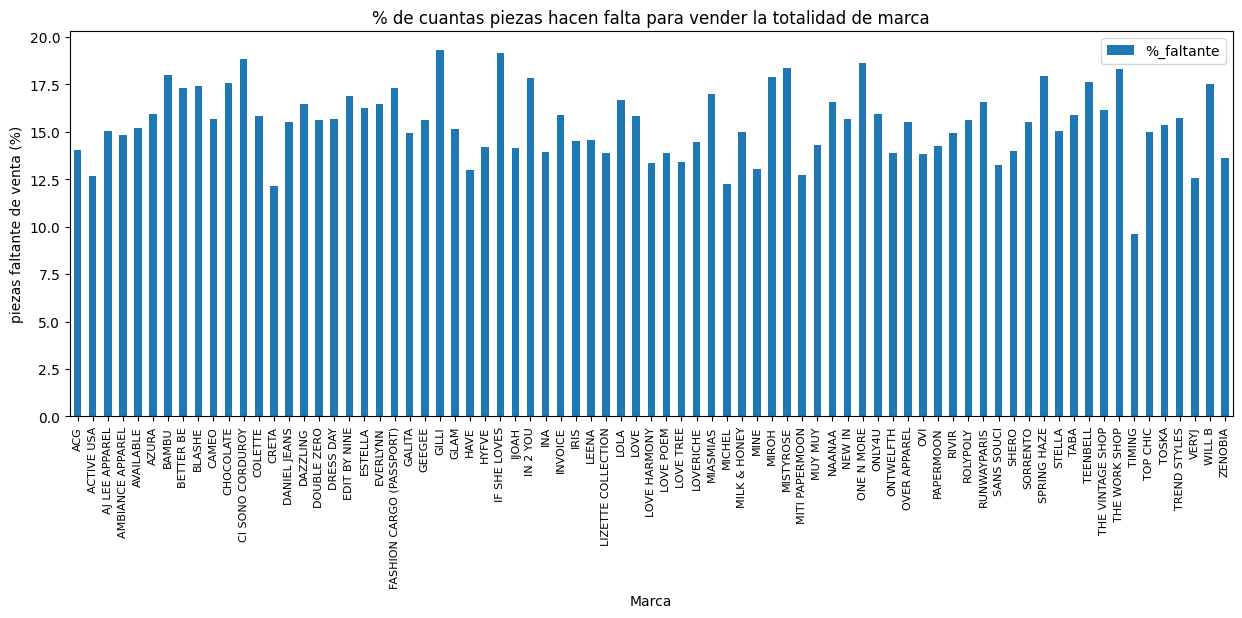

In [178]:
stock_marca.plot(kind='bar',x='marca', y='%_faltante', figsize=(15,5))
plt.title('% de cuantas piezas hacen falta para vender la totalidad de marca')
plt.xlabel('Marca')
plt.ylabel('piezas faltante de venta (%)')
plt.xticks(rotation=90,fontsize=8)
plt.show()

la tabla de arriba dice cuanto porcentaje hacen falta de vender para que se venda toda la marca y la tabla de abajo dice el porcentaje por marca que hace falta vender.

In [179]:
participacion_marca=(inv_general.groupby('marca')['stock'].sum())/(inv_general['stock'].sum())*100

In [180]:
participacion_marca=participacion_marca.reset_index(name='%_faltante_venta')
participacion_marca

,marca,%_faltante_venta
0,ACG,1.086589
1,ACTIVE USA,12.053895
2,AJ LEE APPAREL,0.637466
3,AMBIANCE APPAREL,1.825470
4,AVAILABLE,1.598493
...,...,...
72,TOSKA,0.956198
73,TREND STYLES,0.280099
74,VERYJ,0.193171
75,WILL B,0.835466


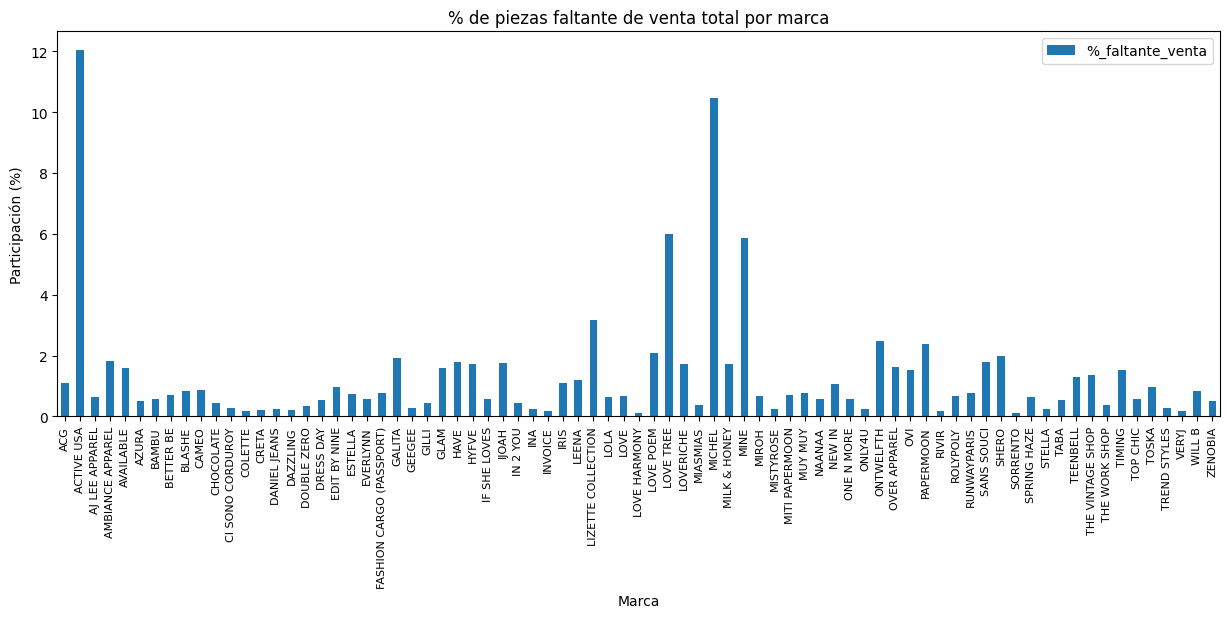

In [181]:
participacion_marca.plot(kind='bar',x='marca',y='%_faltante_venta', figsize=(15,5))
plt.title('% de piezas faltante de venta total por marca')
plt.xlabel('Marca')
plt.ylabel('Participación (%)')
plt.xticks(rotation=90,fontsize=8)
plt.show()

# 7 visualizacion de datos outlier

Visializaremos como el conjunto de datos se comportan.

Text(0.5, 1.0, 'distribucion de stock sobrante por marca')

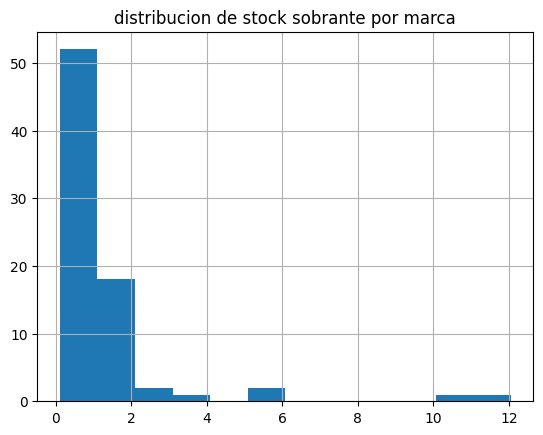

In [182]:
participacion_marca.hist(bins=12)
plt.title('distribucion de stock sobrante por marca')

en este histograma podemos obervar que la gran mayoria de marcas se encuentran en el grupo con menos de 2% de participacion de los productos faltantes.

In [183]:
participacion_marca.describe()

,%_faltante_venta
count,77.000000
mean,1.298701
std,1.942026
min,0.106244
25%,0.429806
50%,0.700246
75%,1.598493
max,12.053895


ahora podemos visualizar los datos outlier para su visualizacion

In [184]:
outlier_marca=participacion_marca[participacion_marca['%_faltante_venta']>=6].reset_index()
outlier_marca


,index,marca,%_faltante_venta
0,1,ACTIVE USA,12.053895
1,40,LOVE TREE,6.002801
2,43,MICHEL,10.469889


se encontraron 3 marcas que son las que mas productos tienen en el inventario (28.52%)
- ACTIVE USA
- LOVE TREE
- MICHEL

antes de tomar decisiones debemos aclarar dos puntos
- estas marcas tiene mas volumen de compra.
- debemos saber cuanto tiempo tardan en venderse cada sku.

## 7.1 volumen de compra

In [185]:
compras_total_marca=\
 (compras_raw.groupby('marca')['cantidad'].sum())\
.reset_index(name='cantidad_total_compra')

compras_total_marca['%_compra_marca']=\
 compras_total_marca['cantidad_total_compra']\
 /compras_total_marca['cantidad_total_compra'].sum()*100

compras_total_marca

,marca,cantidad_total_compra,%_compra_marca
0,ACG,1605,1.089081
1,ACTIVE USA,19680,13.353961
2,AJ LEE APPAREL,876,0.594414
3,AMBIANCE APPAREL,2553,1.732351
4,AVAILABLE,2178,1.477893
...,...,...,...
72,TOSKA,1290,0.875336
73,TREND STYLES,369,0.250387
74,VERYJ,318,0.215780
75,WILL B,987,0.669734


Text(0, 0.5, 'Participación (%)')

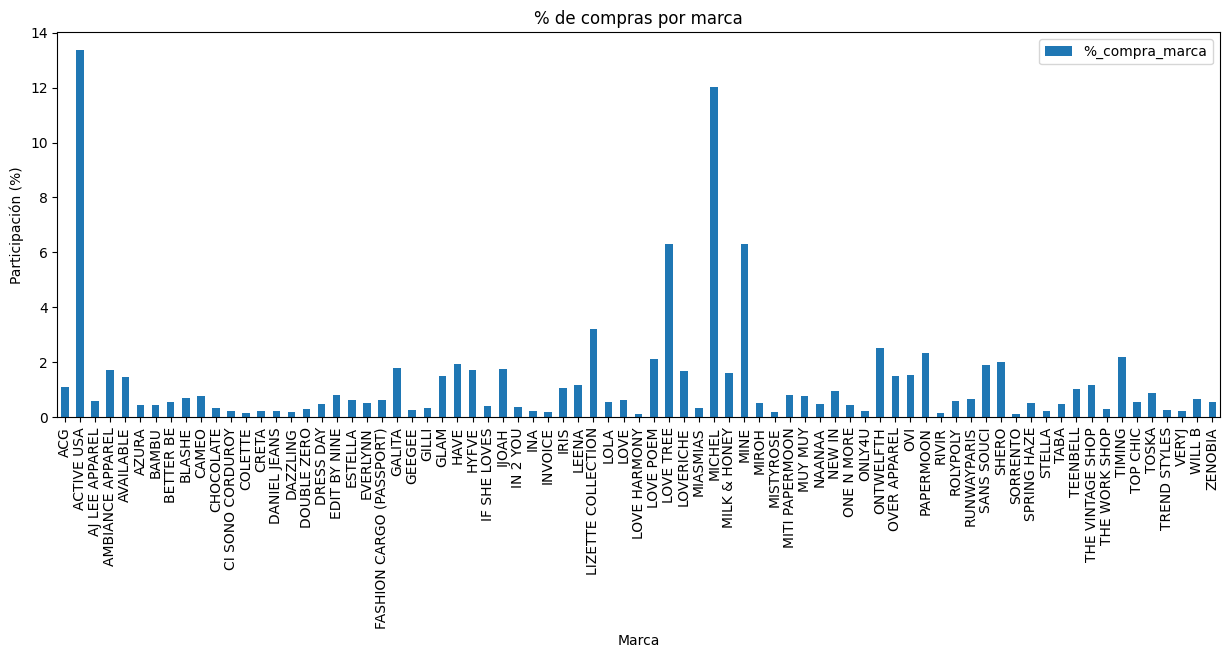

In [186]:
compras_total_marca.plot(kind='bar',x='marca',y='%_compra_marca', figsize=(15,5))
plt.title('% de compras por marca')
plt.xlabel('Marca')
plt.ylabel('Participación (%)')

Text(0.5, 1.0, 'distribucion de compras por marca')

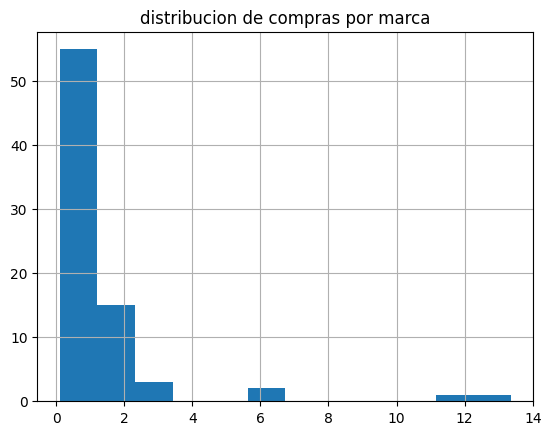

In [187]:
compra_total_marca_hist=compras_total_marca[['%_compra_marca']]
compra_total_marca_hist.hist(bins=12)
plt.title('distribucion de compras por marca')

In [188]:
outlier_compra=compras_total_marca[compras_total_marca['%_compra_marca']>6]
outlier_compra

,marca,cantidad_total_compra,%_compra_marca
1,ACTIVE USA,19680,13.353961
40,LOVE TREE,9288,6.302418
43,MICHEL,17712,12.018565
45,MINE,9288,6.302418


In [189]:
comparacion_compras=outlier_compra.merge(outlier_marca, on='marca', how='left')
comparacion_compras[['marca','%_compra_marca','%_faltante_venta']]

,marca,%_compra_marca,%_faltante_venta
0,ACTIVE USA,13.353961,12.053895
1,LOVE TREE,6.302418,6.002801
2,MICHEL,12.018565,10.469889
3,MINE,6.302418,NaN


existe una relacion directa entre la cantidad de compra por marca y la cantidad de stock que existe.

en pocas palabras hay mas stock de esa marca porque se compro mas producto de esa marca.

## 7.2 seguimiento de sku a traves del tiempo

Realizaremos la trazabilidad para sacar tiempos de cada sku tardan en venderse

In [196]:
compra_sku=dcompra_raw[['fecha','sku','marca','cantidad','precio_unitario']]
compra_sku=compra_sku.rename(columns={'fecha':'fecha_compra','precio_unitario':'costo_producto','cantidad':'cantidad_compra'})
compra_sku

,fecha_compra,sku,marca,cantidad_compra,costo_producto
0,2024-01-04 00:00:00+00:00,GEE-0001,GEEGEE,9,265
1,2024-01-04 00:00:00+00:00,GEE-0002,GEEGEE,9,253
2,2024-01-04 00:00:00+00:00,INA-0001,INA,9,291
3,2024-01-04 00:00:00+00:00,INA-0002,INA,9,289
4,2024-01-04 00:00:00+00:00,HAV-0001,HAVE,18,149
...,...,...,...,...,...
7644,2025-12-06 00:00:00+00:00,AMB-0187,AMBIANCE APPAREL,18,148
7645,2025-12-06 00:00:00+00:00,AMB-0188,AMBIANCE APPAREL,18,194
7646,2025-12-06 00:00:00+00:00,AMB-0189,AMBIANCE APPAREL,21,166
7647,2025-12-06 00:00:00+00:00,AMB-0190,AMBIANCE APPAREL,18,91


In [197]:
venta_sku=dventa_raw[['fecha','sku','marca','cantidad','precio_venta_producto']]
venta_sku=venta_sku.rename(columns={'fecha':'fecha_venta','cantidad':'cantidad_venta'})
venta_sku


,fecha_venta,sku,marca,cantidad_venta,precio_venta_producto
0,2024-01-05 00:00:00+00:00,HAV-0007,HAVE,1,193
1,2024-01-05 00:00:00+00:00,OVI-0010,OVI,1,318
2,2024-01-05 00:00:00+00:00,SPR-0004,SPRING HAZE,1,320
3,2024-01-05 00:00:00+00:00,ACT-0011,ACTIVE USA,1,190
4,2024-01-05 00:00:00+00:00,HAV-0005,HAVE,1,310
...,...,...,...,...,...
126464,2026-12-26 00:00:00+00:00,ACT-0345,ACTIVE USA,1,171
126465,2026-12-27 00:00:00+00:00,MIC-0331,MICHEL,1,310
126466,2026-12-27 00:00:00+00:00,MIC-0325,MICHEL,1,143
126467,2026-12-28 00:00:00+00:00,LEE-0149,LEENA,1,451


In [224]:
cohorte_union=compra_sku.merge(venta_sku, on='sku', how='left')
cohorte_union=cohorte_union[['fecha_compra','fecha_venta','sku','marca_x','cantidad_compra','cantidad_venta']]
cohorte_union

,fecha_compra,fecha_venta,sku,marca_x,cantidad_compra,cantidad_venta
0,2024-01-04 00:00:00+00:00,2024-01-06 00:00:00+00:00,GEE-0001,GEEGEE,9,1
1,2024-01-04 00:00:00+00:00,2024-01-15 00:00:00+00:00,GEE-0001,GEEGEE,9,1
2,2024-01-04 00:00:00+00:00,2024-01-23 00:00:00+00:00,GEE-0001,GEEGEE,9,1
3,2024-01-04 00:00:00+00:00,2024-01-25 00:00:00+00:00,GEE-0001,GEEGEE,9,1
4,2024-01-04 00:00:00+00:00,2024-01-28 00:00:00+00:00,GEE-0001,GEEGEE,9,1
...,...,...,...,...,...,...
126464,2025-12-06 00:00:00+00:00,2026-04-02 00:00:00+00:00,AMB-0191,AMBIANCE APPAREL,21,1
126465,2025-12-06 00:00:00+00:00,2026-04-04 00:00:00+00:00,AMB-0191,AMBIANCE APPAREL,21,1
126466,2025-12-06 00:00:00+00:00,2026-04-14 00:00:00+00:00,AMB-0191,AMBIANCE APPAREL,21,1
126467,2025-12-06 00:00:00+00:00,2026-04-21 00:00:00+00:00,AMB-0191,AMBIANCE APPAREL,21,1


caclular el mes/anio de compra de cada sku

In [226]:
cohorte_union['cohorte_compra']=cohorte_union['fecha_compra'].dt.to_period('M')
cohorte_union['cohorte_venta']=cohorte_union['fecha_venta'].dt.to_period('M')
cohorte_union

/tmp/ipykernel_3347/46045080.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cohorte_union['cohorte_compra']=cohorte_union['fecha_compra'].dt.to_period('M')
/tmp/ipykernel_3347/46045080.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cohorte_union['cohorte_venta']=cohorte_union['fecha_venta'].dt.to_period('M')


,fecha_compra,fecha_venta,sku,marca_x,cantidad_compra,cantidad_venta,cohorte_compra,cohorte_venta
0,2024-01-04 00:00:00+00:00,2024-01-06 00:00:00+00:00,GEE-0001,GEEGEE,9,1,2024-01,2024-01
1,2024-01-04 00:00:00+00:00,2024-01-15 00:00:00+00:00,GEE-0001,GEEGEE,9,1,2024-01,2024-01
2,2024-01-04 00:00:00+00:00,2024-01-23 00:00:00+00:00,GEE-0001,GEEGEE,9,1,2024-01,2024-01
3,2024-01-04 00:00:00+00:00,2024-01-25 00:00:00+00:00,GEE-0001,GEEGEE,9,1,2024-01,2024-01
4,2024-01-04 00:00:00+00:00,2024-01-28 00:00:00+00:00,GEE-0001,GEEGEE,9,1,2024-01,2024-01
...,...,...,...,...,...,...,...,...
126464,2025-12-06 00:00:00+00:00,2026-04-02 00:00:00+00:00,AMB-0191,AMBIANCE APPAREL,21,1,2025-12,2026-04
126465,2025-12-06 00:00:00+00:00,2026-04-04 00:00:00+00:00,AMB-0191,AMBIANCE APPAREL,21,1,2025-12,2026-04
126466,2025-12-06 00:00:00+00:00,2026-04-14 00:00:00+00:00,AMB-0191,AMBIANCE APPAREL,21,1,2025-12,2026-04
126467,2025-12-06 00:00:00+00:00,2026-04-21 00:00:00+00:00,AMB-0191,AMBIANCE APPAREL,21,1,2025-12,2026-04


In [229]:
cohorte_union.groupby(['cohorte_compra','sku'])['cantidad_compra'].sum()

cohorte_compra  sku     
2024-01         ACG-0001     63
                ACG-0002     63
                ACG-0003     63
                ACG-0004     63
                ACG-0005     81
                           ... 
2025-12         WIL-0098     63
                WIL-0099     63
                WIL-0100     63
                WIL-0101     72
                WIL-0102    120
Name: cantidad_compra, Length: 7649, dtype: int64

calcular cada mes/anio que se vendio cada sku a traves del tiempo, ver la manera de sacar % de venta por mes

fecha_venta                sku     
2024-01-05 00:00:00+00:00  ACG-0002    1
                           ACG-0003    1
                           ACG-0010    1
                           ACT-0001    2
                           ACT-0004    3
                                      ..
2026-12-26 00:00:00+00:00  MIC-0331    1
2026-12-27 00:00:00+00:00  MIC-0325    1
                           MIC-0331    1
2026-12-28 00:00:00+00:00  LEE-0149    1
                           LIZ-0154    1
Name: cantidad_venta, Length: 99976, dtype: int64

# 8 Análisis de Break-even y Periodo de Recuperación por Cohortes mensuales

Análisis Dinámico de Recuperación de Capital por Cohortes Mensuales (2024-2025). Este modelo evalúa el ciclo de vida financiero de cada lote de mercancía, comparando la curva de ingresos acumulados contra la inversión inicial. Permite identificar patrones estacionales de retorno y optimizar el flujo de caja mediante la visualización del Punto de Equilibrio (Break-even) multitemporal.